# Évaluation des Modèles

In [ ]:
import sys, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from src.evaluation.evaluator import TimeSeriesEvaluator
from src.models.prophet import ProphetRegressor
from src.models.fourier import FourierRegressor
from src.models.baselines import AverageRegressor, LastWeekRegressor, YesterdayRegressor, LinearRegressor, SimilarDayRegressor
from src.models.xgboost_regressor import XGBoostRegressor
from src.models.lstm_regressor import LSTMRegressor
from src.models.sarimax import SARIMAXRegressor

df = pd.read_csv('../data/processed/dataset_final.csv')

evaluator = TimeSeriesEvaluator(df, "perfect")

val_start = pd.to_datetime('2024-01-01').tz_localize('Europe/Paris')
test_start = pd.to_datetime('2025-01-01').tz_localize('Europe/Paris')

df_train, df_val, df_test = evaluator.split_data(val_start, test_start, load_existing_splits=True)

CONSUMPTION_COLS = [
    'consommation_mw_tendance_24h_derniere_connue',
    'consommation_mw_tendance_6h_derniere_connue',
    'consommation_mw_min_24h_derniere_connue', 'consommation_mw_max_24h_derniere_connue',
    'consommation_mw_moyenne_24h_derniere_connue',
    'consommation_mw_meme_heure_derniere_connue',
    'consommation_mw_derniere_connue',
    'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366',
]

CALENDER_COLS = [
    'cible_heure_sin', 'cible_heure_cos',
    'cible_jour_semaine_sin','cible_jour_semaine_cos',
    'cible_jour_annee_sin','cible_jour_annee_cos',
    'heure', 'jour_semaine', 'jour_annee', 'mois', 'saison','saison_meteorologique', 'annee',
    'weekend', 'ferie', 'vacances', 'confinement_numero',
]

TEMPERATURE_COLS = [
	'temperature_c_pondere_pop_meme_heure_derniere_connue',
	'temperature_c_pondere_pop_derniere_connue',
	'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366',
	'temperature_c_pondere_pop_moyenne_24h_derniere_connue',
	'temperature_c_pondere_pop_min_24h_derniere_connue',
	'temperature_c_pondere_pop_max_24h_derniere_connue',
	'temperature_c_pondere_pop_moyenne_48h_derniere_connue',
	'temperature_c_pondere_pop_moyenne_72h_derniere_connue',
	'temperature_c_pondere_pop_tendance_6h_derniere_connue',
	'temperature_c_pondere_pop_tendance_24h_derniere_connue',
	'temperature_c_pondere_pop_sous_15_derniere_connue',
	'temperature_c_pondere_pop_au_dessus_22_derniere_connue',
	'temperature_c_pondere_pop_sous_15_cumul_3j_derniere_connue',
	'temperature_c_pondere_pop_ecart_normale_derniere_connue'
]

Importing plotly failed. Interactive plots will not work.


## Modèles de Références

In [ ]:
# _, best_average = evaluator.grid_search_rolling_validation(AverageRegressor, [{}])
_, best_lastweek = evaluator.grid_search_rolling_validation(LastWeekRegressor, [{}])
_, best_yesterday = evaluator.grid_search_rolling_validation(YesterdayRegressor, [{}])
_, best_similar = evaluator.grid_search_rolling_validation(
    SimilarDayRegressor,
    {
		"k": [2],
		"temp_weight": [100.0]
	}
);

In [ ]:
_, best_linear = evaluator.grid_search_rolling_validation(
    LinearRegressor,
    [{"features_cols": [[
		'consommation_mw_meme_heure_derniere_connue',
        'consommation_mw_derniere_connue',
		'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366',
		'heure', 'jour_semaine', 'jour_annee', 'mois', 'annee', 'weekend', 'ferie', 'vacances',
	]]}]
);

## Fourier Regression

In [25]:
_, best_fourier = evaluator.grid_search_rolling_validation(
    FourierRegressor,
    [
		{
			"features_cols": [CONSUMPTION_COLS + CALENDER_COLS + TEMPERATURE_COLS],
			"fourier_orders": [{'yearly': 15, 'weekly': 15, 'daily': 15}]
		},
	]
);

Grid Search de FourierRegressor :

Combination 1/1 : {'features_cols': ['consommation_mw_tendance_24h_derniere_connue', 'consommation_mw_tendance_6h_derniere_connue', 'consommation_mw_min_24h_derniere_connue', 'consommation_mw_max_24h_derniere_connue', 'consommation_mw_moyenne_24h_derniere_connue', 'consommation_mw_meme_heure_derniere_connue', 'consommation_mw_derniere_connue', 'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366', 'cible_heure_sin', 'cible_heure_cos', 'cible_jour_semaine_sin', 'cible_jour_semaine_cos', 'cible_jour_annee_sin', 'cible_jour_annee_cos', 'heure', 'jour_semaine', 'jour_annee', 'mois', 'saison', 'saison_meteorologique', 'annee', 'weekend', 'ferie', 'vacances', 'confinement_numero', 'temperature_c_pondere_pop_meme_heure_derniere_connue', 'temperature_c_pondere_pop_derniere_connue', 'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366', 'temperature_c_pondere_pop_moyenne_24h_derniere_connue', 'temperature_c_

# Prophet

In [30]:
_, best_prophet = evaluator.grid_search_rolling_validation(
    ProphetRegressor,
    [
		{
			"history_days": [3 * 366],
			"features_cols": [TEMPERATURE_COLS]
        }
    ]
);

Grid Search de ProphetRegressor :

Combination 1/1 : {'features_cols': ['temperature_c_pondere_pop_meme_heure_derniere_connue', 'temperature_c_pondere_pop_derniere_connue', 'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366', 'temperature_c_pondere_pop_moyenne_24h_derniere_connue', 'temperature_c_pondere_pop_min_24h_derniere_connue', 'temperature_c_pondere_pop_max_24h_derniere_connue', 'temperature_c_pondere_pop_moyenne_48h_derniere_connue', 'temperature_c_pondere_pop_moyenne_72h_derniere_connue', 'temperature_c_pondere_pop_tendance_6h_derniere_connue', 'temperature_c_pondere_pop_tendance_24h_derniere_connue', 'temperature_c_pondere_pop_sous_15_derniere_connue', 'temperature_c_pondere_pop_au_dessus_22_derniere_connue', 'temperature_c_pondere_pop_sous_15_cumul_3j_derniere_connue', 'temperature_c_pondere_pop_ecart_normale_derniere_connue'], 'history_days': 1098}
Évaluation de ProphetRegressor | 8784 lignes | réentraînement/6ME | 3 itérations


00:54:27 - cmdstanpy - INFO - Chain [1] start processing
00:54:30 - cmdstanpy - INFO - Chain [1] done processing


Progression: 2024-01-01 00:00...

00:54:35 - cmdstanpy - INFO - Chain [1] start processing
00:54:38 - cmdstanpy - INFO - Chain [1] done processing


Progression: 2024-01-31 00:00...

00:54:43 - cmdstanpy - INFO - Chain [1] start processing
00:54:45 - cmdstanpy - INFO - Chain [1] done processing


Progression: 2024-07-31 00:00...
Train : MAE = 1791.38 MW |RMSE = 2309.35 MW |MAPE = 3.49%


Validation : MAE = 1720.25 MW |RMSE = 2240.23 MW |MAPE = 3.50%

Best MAE sur Validation : 1720.25 MW
Best Params : {'features_cols': ['temperature_c_pondere_pop_meme_heure_derniere_connue', 'temperature_c_pondere_pop_derniere_connue', 'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366', 'temperature_c_pondere_pop_moyenne_24h_derniere_connue', 'temperature_c_pondere_pop_min_24h_derniere_connue', 'temperature_c_pondere_pop_max_24h_derniere_connue', 'temperature_c_pondere_pop_moyenne_48h_derniere_connue', 'temperature_c_pondere_pop_moyenne_72h_derniere_connue', 'temperature_c_pondere_pop_tendance_6h_derniere_connue', 'temperature_c_pondere_pop_tendance_24h_derniere_connue', 'temperature_c_pondere_pop_sous_15_derniere_connue', 'temperature_c_pondere_pop_au_dessus_22_derniere_connue', 'temperature_c_pondere_pop_sous_15_cumul_3j_derniere_connue', 'temperature_c_pondere_pop_ec

# XGBoost

In [31]:
_, best_xgb = evaluator.grid_search_rolling_validation(
    XGBoostRegressor,
    [{}]
);

Grid Search de XGBoostRegressorCustom :

Combination 1/1 : {}
Évaluation de XGBoostRegressorCustom | 8784 lignes | réentraînement/6ME | 3 itérations

Nombre d'arbres réellement retenus (best_iteration) : 2983 / 3000
Meilleure MAE validation : 871.25
Progression: 2024-01-01 00:00...
Nombre d'arbres réellement retenus (best_iteration) : 2996 / 3000
Meilleure MAE validation : 1289.09
Progression: 2024-01-31 00:00...
Nombre d'arbres réellement retenus (best_iteration) : 552 / 3000
Meilleure MAE validation : 475.81
Progression: 2024-07-31 00:00...
Train : MAE = 548.95 MW |RMSE = 816.36 MW |MAPE = 1.04%


Validation : MAE = 889.25 MW |RMSE = 1236.53 MW |MAPE = 1.76%

Best MAE sur Validation : 889.25 MW
Best Params : {}



# SARIMAX

In [ ]:
import itertools

p = [2]
d = [0, 1]
q = [2]
orders = list(itertools.product(p, d, q))

P = [1]
D = [1]
Q = [1]
seasonal_orders = [(*x, 24) for x in itertools.product(P, D, Q)]

_, best_sarimax = evaluator.grid_search_rolling_validation(SARIMAXRegressor, [
	{
		"order": orders,
		"seasonal_order": seasonal_orders,
		"features_cols": [
			CONSUMPTION_COLS +
			CALENDER_COLS +
			TEMPERATURE_COLS
		],
		"since_year": [2023]
	}
]);

Grid Search de SARIMAXRegressor :

Combination 1/2 : {'features_cols': ['consommation_mw_tendance_24h_derniere_connue', 'consommation_mw_tendance_6h_derniere_connue', 'consommation_mw_min_24h_derniere_connue', 'consommation_mw_max_24h_derniere_connue', 'consommation_mw_moyenne_24h_derniere_connue', 'consommation_mw_meme_heure_derniere_connue', 'consommation_mw_derniere_connue', 'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366', 'cible_heure_sin', 'cible_heure_cos', 'cible_jour_semaine_sin', 'cible_jour_semaine_cos', 'cible_jour_annee_sin', 'cible_jour_annee_cos', 'heure', 'jour_semaine', 'jour_annee', 'mois', 'saison', 'saison_meteorologique', 'annee', 'weekend', 'ferie', 'vacances', 'confinement_numero', 'temperature_c_pondere_pop_meme_heure_derniere_connue', 'temperature_c_pondere_pop_derniere_connue', 'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366', 'temperature_c_pondere_pop_moyenne_24h_derniere_connue', 'temperature_c_

# LSTM

In [ ]:
_, best_lstm = evaluator.grid_search_rolling_validation(
	LSTMRegressor,
	[{}],
	freq="15ME"
);

# Test

In [ ]:
# evaluator.rolling_test(best_average["model"]);
evaluator.rolling_test(best_lastweek["model"]);
evaluator.rolling_test(best_yesterday["model"]);
evaluator.rolling_test(best_linear["model"]);
evaluator.rolling_test(best_fourier["model"]);
evaluator.rolling_test(best_similar["model"]);
evaluator.rolling_test(best_prophet["model"]);
evaluator.rolling_test(best_xgb["model"]);
evaluator.rolling_test(best_sarimax["model"]);
evaluator.rolling_test(best_lstm["model"]);

## Visualisation

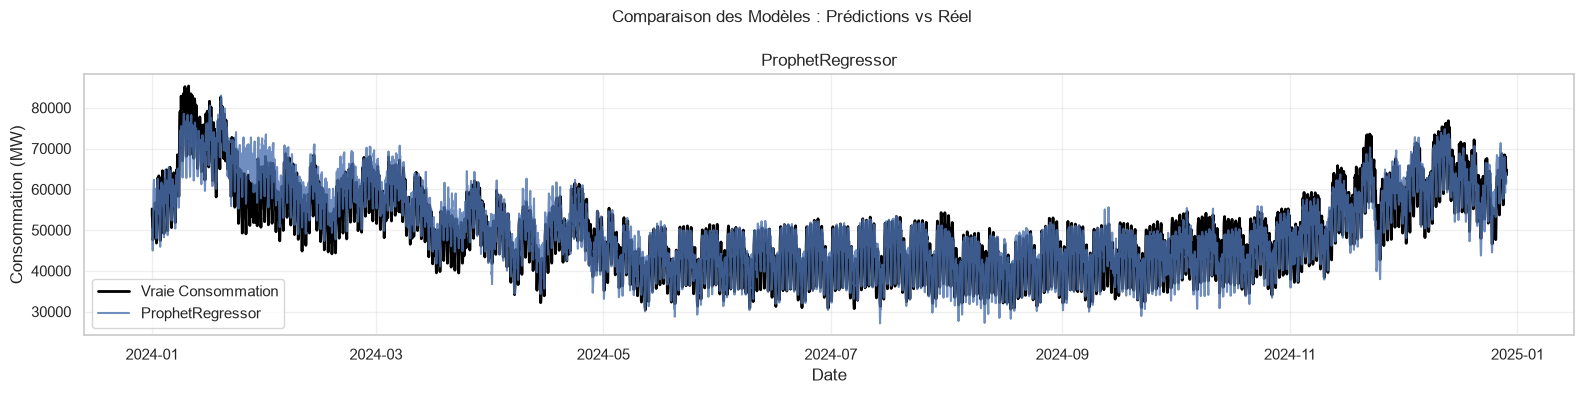

In [4]:
# Zoomons sur le mois de Janvier 2024
start_zoom = pd.to_datetime('2024-01-01').tz_localize('Europe/Paris')
end_zoom = pd.to_datetime('2024-12-29').tz_localize('Europe/Paris')

evaluator.plot_predictions(use_test=False, start_date=start_zoom, end_date=end_zoom)

In [ ]:
evaluator.plot_feature_importances(top_n=30)

In [ ]:
evaluator.plot_train_val_test_metrics()

In [ ]:
evaluator.plot_error_per_horizon()

In [ ]:
evaluator.plot_advanced_metrics()